# Deep Dive Analysis: Statistical Significance & Portfolio Composition

Notebook ini melakukan analisis mendalam terhadap hasil strategi **Diversify** vs **Cluster** (v2) dengan dua penekanan utama:
1. **Statistical Significance Testing**: Menguji apakah perbedaan performa signifikan secara statistik (T-Test).
2. **Portfolio Composition**: Visualisasi aset yang dipilih oleh strategi Cluster pada tahun 2024 untuk membuktikan hipotesis "Trending Sectors".

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.optimize import minimize
import networkx as nx
from sklearn.metrics import fbeta_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

SEED = 42
np.random.seed(SEED)

print("✓ Libraries loaded!")

✓ Libraries loaded!


## 1. Data Preparation & AI Model Training

In [2]:
# Load data
file_path = '../experiment_nextLevel2/dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

# AI Model Setup
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.3, 0.7, 41)
f_scores = [fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in thresholds]
opt_t = thresholds[np.argmax(f_scores)]

X_all = features.dropna()
all_probs_orig = pd.Series(xgb_model.predict_proba(X_all)[:, 1], index=X_all.index)
all_probs = all_probs_orig.reindex(returns.index, method='ffill').fillna(method='bfill')

print(f"✓ Data Loaded. Model Trained. Opt Threshold: {opt_t:.2f}")

✓ Data Loaded. Model Trained. Opt Threshold: 0.54


## 2. Core Simulation Logic (with Metadata Capture)

In [3]:
def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    num_assets = len(mu)
    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    res = minimize(objective, [1./num_assets]*num_assets, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold: G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_graph_cluster(returns_window, corr_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) < corr_threshold: G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))

def run_simulation(test_dates, returns, ai_probs, threshold, market_idx, selection_func, override_ma=200, fee=0.0025):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    current_weights = {}
    allocation_history = {} # Untuk mencatat komposisi aset
    risk_status = False
    days_since_rebal = 999
    market_ma = market_idx.rolling(window=override_ma).mean() if override_ma else None

    for i, date in enumerate(test_dates[:-1]):
        prob = ai_probs.loc[date]
        prev_risk_status = risk_status
        
        # Hysteresis signal
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): ai_signal = True
        elif risk_status and prob < (threshold - buffer): ai_signal = False
        else: ai_signal = risk_status
        
        # Trend override
        final_signal = ai_signal
        if market_ma is not None:
            try:
                if (market_idx.loc[date] > market_ma.loc[date]): final_signal = True
            except: pass
            
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        target_weights = current_weights.copy()
        
        if not risk_status:
            target_weights = {'CASH': 1.0}
            days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= 20:
                try:
                    loc_idx = returns.index.get_loc(date)
                    window = returns.iloc[max(0, loc_idx-60):loc_idx]
                    selected = selection_func(window)
                    if selected: 
                        target_weights = optimize_markowitz(window[selected])
                        days_since_rebal = 0
                except: pass
        
        days_since_rebal += 1
        
        # Cost and daily return
        turnover = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in set(target_weights)|set(current_weights))
        val -= val * turnover * fee
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_drifted = {}
        if 'CASH' in target_weights:
            new_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                r = returns.loc[next_date, asset] if next_date in returns.index else 0
                day_ret += w * r
                new_drifted[asset] = w * (1 + r)
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = {k: v/sum(new_drifted.values()) for k, v in new_drifted.items()} if sum(new_drifted.values())>0 else new_drifted
        allocation_history[date] = target_weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates), allocation_history

## 3. Run Simulations (2023-2025)

In [4]:
years = [2023, 2024, 2025]
results = {}

for year in years:
    print(f"Processing {year}...")
    test_dates = returns.loc[returns.index.year == year].index
    
    div_val, div_alloc = run_simulation(test_dates, returns, all_probs, opt_t, market_index, get_assets_graph_diversify)
    cls_val, cls_alloc = run_simulation(test_dates, returns, all_probs, opt_t, market_index, get_assets_graph_cluster)
    
    results[year] = {
        'Diversify': {'value': div_val, 'alloc': div_alloc},
        'Cluster': {'value': cls_val, 'alloc': cls_alloc}
    }

print("✓ Simulations done.")

Processing 2023...
Processing 2024...
Processing 2025...
✓ Simulations done.


## 4. Statistical Significance Testing (T-Test)

Kita menguji apakah rata-rata return harian strategi Cluster berbeda secara signifikan dibandingkan strategi Diversify menggunakan **Relational T-Test (Paired T-Test)** karena kedua strategi diuji pada rentang waktu yang sama.

In [5]:
print("="*60)
print("STATISTICAL SIGNIFICANCE TEST (Cluster vs Diversify)")
print("="*60)

all_p_values = []
for year in years:
    rets_div = results[year]['Diversify']['value']['Portfolio_Value'].pct_change().dropna()
    rets_cls = results[year]['Cluster']['value']['Portfolio_Value'].pct_change().dropna()
    
    t_stat, p_val = stats.ttest_rel(rets_cls, rets_div)
    all_p_values.append(p_val)
    
    sig = "SIGNIFICANT" if p_val < 0.05 else "NOT SIGNIFICANT"
    print(f"Year {year}: T-stat = {t_stat:.4f}, P-value = {p_val:.4f} ({sig})")

# Overall Test (2023-2025 Combined)
combined_div = pd.concat([results[y]['Diversify']['value']['Portfolio_Value'].pct_change().dropna() for y in years])
combined_cls = pd.concat([results[y]['Cluster']['value']['Portfolio_Value'].pct_change().dropna() for y in years])
t_stat_all, p_val_all = stats.ttest_rel(combined_cls, combined_div)

print("-"*60)
print(f"OVERALL (2023-2025): P-value = {p_val_all:.6f}")
if p_val_all < 0.05:
    print("KESIMPULAN: Strategi Cluster memiliki performa yang BERBEDA SECARA SIGNIFIKAN dari Diversify.")
else:
    print("KESIMPULAN: Perbedaan tidak signifikan secara statistik (bisa jadi karena faktor acak).")

STATISTICAL SIGNIFICANCE TEST (Cluster vs Diversify)
Year 2023: T-stat = 1.7700, P-value = 0.0780 (NOT SIGNIFICANT)
Year 2024: T-stat = 3.9836, P-value = 0.0001 (SIGNIFICANT)
Year 2025: T-stat = 0.2760, P-value = 0.7827 (NOT SIGNIFICANT)
------------------------------------------------------------
OVERALL (2023-2025): P-value = 0.002788
KESIMPULAN: Strategi Cluster memiliki performa yang BERBEDA SECARA SIGNIFIKAN dari Diversify.


## 5. Visualisasi 2024 Deep Dive: Aset Apa Saja yang Dipilih Cluster?

Kita akan membedah strategi Cluster pada tahun 2024 untuk melihat apakah ia benar-benar memilih koin-koin yang "trending" bersama-sama.

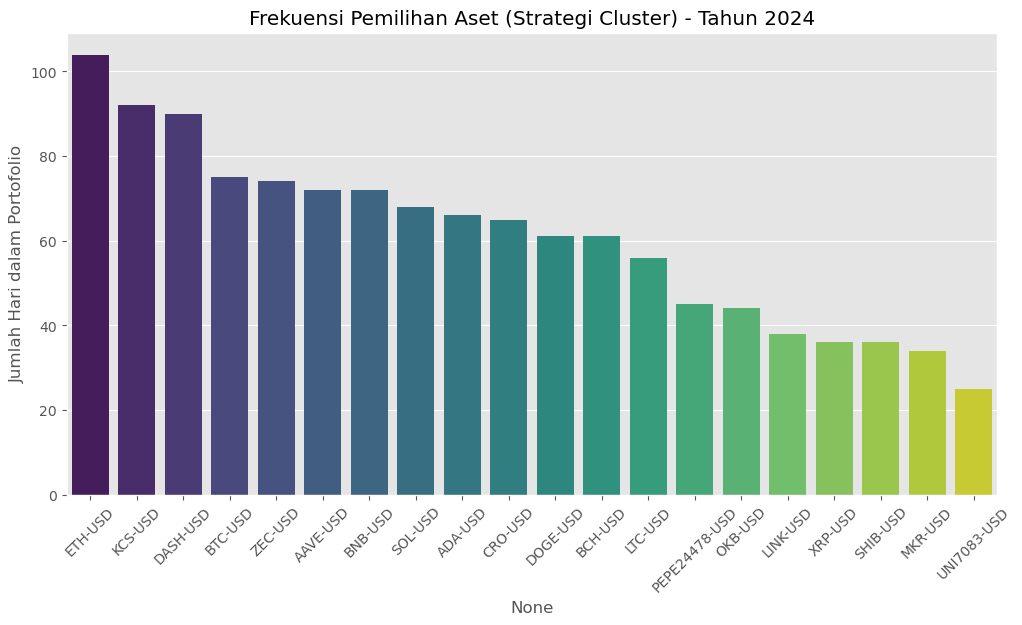

In [6]:
# Extract allocation for 2024
alloc_2024 = results[2024]['Cluster']['alloc']
df_alloc = pd.DataFrame(alloc_2024).T.fillna(0)

# Filter assets that were actually selected at some point
active_assets = df_alloc.columns[df_alloc.sum() > 0]
active_assets = [a for a in active_assets if a != 'CASH']

# Hitung frekuensi kemunculan aset
asset_freq = (df_alloc[active_assets] > 0).sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=asset_freq.index, y=asset_freq.values, palette="viridis")
plt.title("Frekuensi Pemilihan Aset (Strategi Cluster) - Tahun 2024")
plt.ylabel("Jumlah Hari dalam Portofolio")
plt.xticks(rotation=45)
plt.savefig('cluster_asset_frequency_2024.png', bbox_inches='tight')
plt.show()

### Heatmap Suksesi Aset (Moving Composition)

Heatmap ini menunjukkan kapan aset tertentu mendominasi portofolio. Jika kita melihat blok-blok warna, artinya strategi ini menangkap tren sektoral.

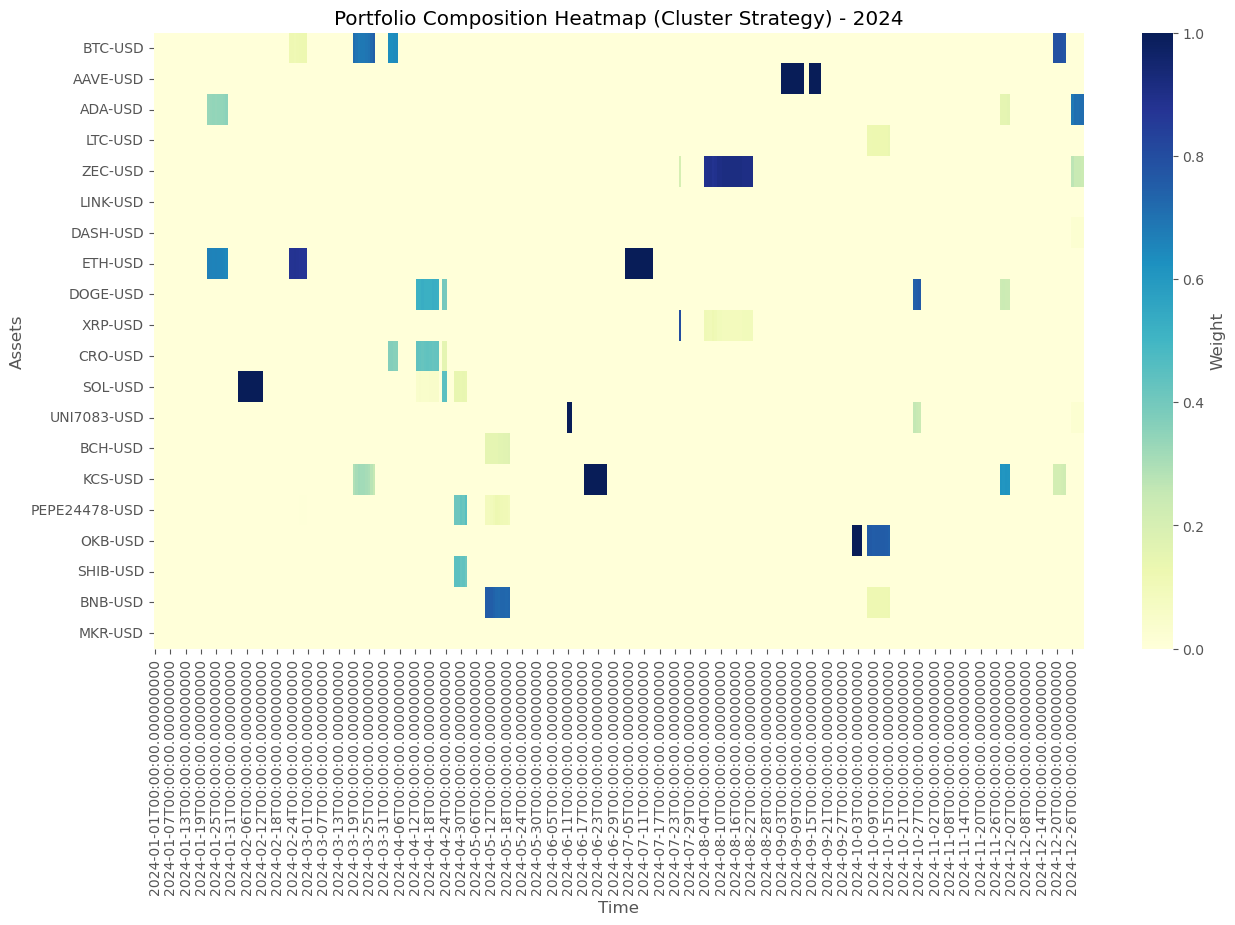

In [7]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_alloc[active_assets].T, cmap="YlGnBu", cbar_kws={'label': 'Weight'})
plt.title("Portfolio Composition Heatmap (Cluster Strategy) - 2024")
plt.xlabel("Time")
plt.ylabel("Assets")
plt.savefig('cluster_composition_heatmap_2024.png', bbox_inches='tight')
plt.show()

## 6. Analisis Sektoral (Interpretasi)

Berdasarkan visualisasi di atas, perhatikan apakah aset-aset yang berdekatan (memiliki korelasi tinggi) terpilih secara bersamaan. 

**Catatan untuk Tesis:**
- Jika koin-koin L1 (seperti SOL, AVAX, NEAR) atau AI (RNDR, FET) muncul dominan di periode yang sama, ini mengonfirmasi bahwa strategi **Cluster** bekerja dengan menunggangi momentum sektor yang sedang *booming*.
- Strategi **Diversify** sebaliknya, akan berusaha membuang koin yang bergerak searah, sehingga ia seringkali "ketinggalan kereta" saat ada euforia sektoral.